<a href="https://colab.research.google.com/github/AliaF123/Laptop_Review/blob/main/laptop_review_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import warnings

from wordcloud import WordCloud

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

from nltk.sentiment import SentimentIntensityAnalyzer

warnings.filterwarnings("ignore")

In [2]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("vader_lexicon")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Laptop_Review/final.csv")

In [4]:
#preview data
df.head(10)

,product_name,overall_rating,no_ratings,no_reviews,rating,title,review,final_review
0,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,"15,210",900,5,Perfect product!,"Loved it, it's my first MacBook that I earned ...","Perfect product! Loved it, it's my first MacBo..."
1,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,"15,210",900,5,Fabulous!,Battery lasted longer than my first relationsh...,Fabulous! Battery lasted longer than my first ...
2,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,"15,210",900,5,Fabulous!,Such a great deal.. very happy with the perfor...,Fabulous! Such a great deal.. very happy with ...
3,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,"15,210",900,4,Delightful,"Awesome build quality and very good display, b...",Delightful Awesome build quality and very good...
4,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,"15,210",900,5,Awesome,When i ordered and came to know about seller r...,Awesome When i ordered and came to know about ...
5,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,"15,210",900,5,Super!,Super product,Super! Super product
6,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,"15,210",900,5,Super!,Go for it..its awesome,Super! Go for it..its awesome
7,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,"15,210",900,5,Mind-blowing purchase,"Best , best and best 🫶🏻👑🍎","Mind-blowing purchase Best , best and best 🫶🏻👑🍎"
8,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,"15,210",900,5,Just wow!,Its really very good and compact device.,Just wow! Its really very good and compact dev...
9,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...,4.7,"15,210",900,5,Brilliant,"Superb built quality, Amazing performance and ...","Brilliant Superb built quality, Amazing perfor..."


In [5]:
df['product_name']

,product_name
0,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...
1,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...
2,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...
3,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...
4,Apple MacBook AIR Apple M2 - (8 GB/256 GB SSD/...
...,...
25933,Lenovo IdeaPad 5 2-in-1 WUXGA IPS AMD Ryzen 7 ...
25934,Lenovo IdeaPad 5 2-in-1 WUXGA IPS AMD Ryzen 7 ...
25935,Lenovo IdeaPad 5 2-in-1 WUXGA IPS AMD Ryzen 7 ...
25936,Lenovo IdeaPad 5 2-in-1 WUXGA IPS AMD Ryzen 7 ...


In [6]:
print("Rows, Columns:", df.shape)

Rows, Columns: (25938, 8)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25938 entries, 0 to 25937
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_name    25938 non-null  object 
 1   overall_rating  25938 non-null  float64
 2   no_ratings      25938 non-null  object 
 3   no_reviews      25938 non-null  object 
 4   rating          25938 non-null  int64  
 5   title           25938 non-null  object 
 6   review          25938 non-null  object 
 7   final_review    24113 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 1.6+ MB


In [8]:
df.isnull().sum()

,0
product_name,0
overall_rating,0
no_ratings,0
no_reviews,0
rating,0
title,0
review,0
final_review,1825


In [9]:
df.duplicated().sum()

np.int64(7122)

In [10]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [11]:
def clean_review(text):

    # Handle missing values
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [12]:
df['clean_review'] = df['review'].apply(clean_review)

In [13]:
df['clean_review']

,clean_review
0,loved first macbook earned hardwork
1,battery lasted longer first relationship day l...
2,great deal happy performance battery lifeorigi...
3,awesome build quality good display battery cam...
4,ordered came know seller reviewi scared condit...
...,...
25933,great balance speed portability reliability ev...
25934,build quality feel premium laptop handle multi...
25935,great balance speed portability reliability ev...
25936,laptop performs well task although battery cou...


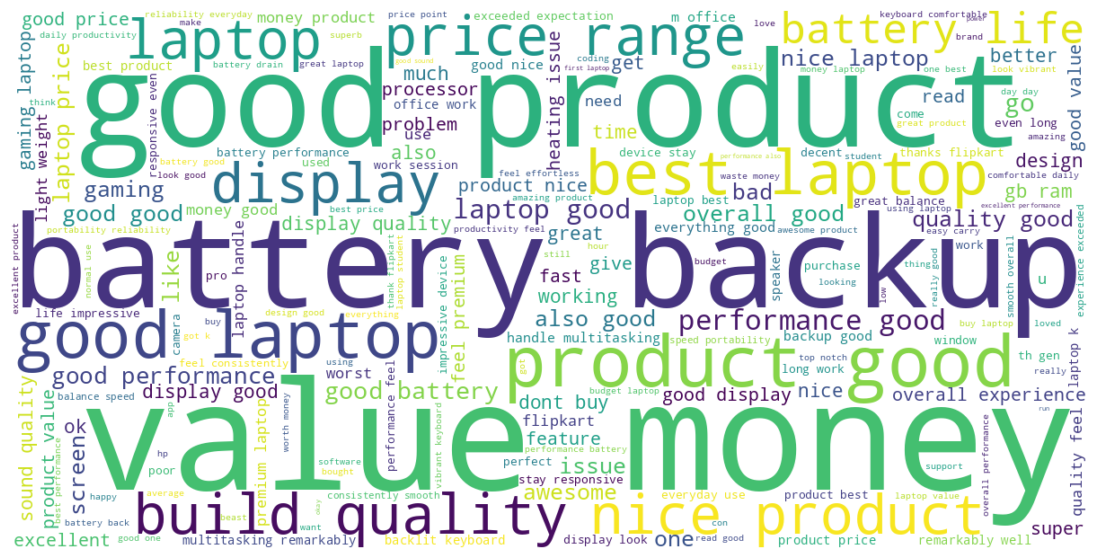

In [14]:

# Select the column that has reviews
text_column = "clean_review"

# Combine all reviews into one big text
text = " ".join(df[text_column].dropna().astype(str))

# Create word cloud
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords={"the","is","and","a","to","it","this","was","for"}
).generate(text)

# Show result
plt.figure(figsize=(14,7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

In [15]:
# Aspect Dictionary
aspect_dict = {

    "performance":[
        "performance",
        "speed",
        "fast",
        "slow",
        "lag",
        "processor",
        "cpu",
        "multitasking"
    ],

    "battery":[
        "battery",
        "charging",
        "charge",
        "backup",
        "power"
    ],

    "display":[
        "display",
        "screen",
        "brightness",
        "resolution",
        "color"
    ],

    "keyboard":[
        "keyboard",
        "typing",
        "trackpad",
        "touchpad"
    ],

    "heating":[
        "heat",
        "heating",
        "thermal",
        "temperature"
    ],

    "price":[
        "price",
        "cost",
        "expensive",
        "cheap",
        "value"
    ],

    "build":[
        "build",
        "design",
        "quality",
        "durable"
    ],

    "portability":[
        "weight",
        "portable",
        "lightweight"
    ]
}

In [16]:
#Keyword Aspect Extraction
def extract_keyword_aspects(text):

    tokens = set(text.split())

    aspects_found = []

    for aspect, keywords in aspect_dict.items():

        if len(tokens.intersection(keywords)) > 0:
            aspects_found.append(aspect)

    return aspects_found

In [17]:
df["keyword_aspects"] = (
    df["clean_review"]
    .apply(extract_keyword_aspects)
)

In [18]:
sia = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = sia.polarity_scores(text)["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["vader_sentiment"] = (
    df["clean_review"]
    .apply(vader_sentiment)
)

df[["review","vader_sentiment"]].head(10)

,review,vader_sentiment
0,"Loved it, it's my first MacBook that I earned ...",Positive
1,Battery lasted longer than my first relationsh...,Positive
2,Such a great deal.. very happy with the perfor...,Positive
3,"Awesome build quality and very good display, b...",Positive
4,When i ordered and came to know about seller r...,Positive
5,Super product,Positive
6,Go for it..its awesome,Positive
7,"Best , best and best 🫶🏻👑🍎",Positive
8,Its really very good and compact device.,Positive
9,"Superb built quality, Amazing performance and ...",Positive


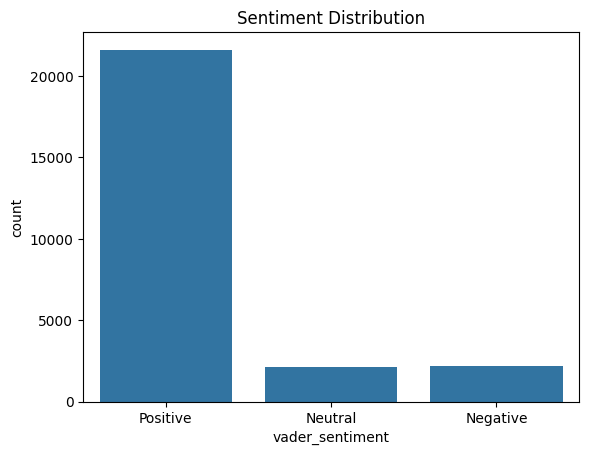

In [19]:
sns.countplot(
    x="vader_sentiment",
    data=df
)

plt.title("Sentiment Distribution")
plt.show()

In [20]:
pip install transformers

In [21]:
pip install torch

In [22]:
from transformers import pipeline

sentiment_pipeline = pipeline(
    "sentiment-analysis"
)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [23]:
sentiment_pipeline(
    "The laptop performance is amazing"
)

[{'label': 'POSITIVE', 'score': 0.9998608827590942}]

In [3]:
import torch

print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

RuntimeError: duplicate registrations for aten.linspace.Tensor_Tensor

In [26]:
import torch
print(torch.cuda.is_available())

False


In [ ]:
df[
    [
        "review",
        "bert_sentiment"
    ]
].head()

In [ ]:
def bert_sentiment_score(text):

    if len(text.strip()) == 0:
        return pd.Series(
            ["Neutral",0]
        )

    result = sentiment_pipeline(
        text[:512]
    )[0]

    return pd.Series(
        [
            result["label"],
            result["score"]
        ]
    )

df[
    [
        "bert_sentiment",
        "bert_score"
    ]
] = df["clean_review"].apply(
    bert_sentiment_score
)

In [ ]:
df["keyword_aspects"]

In [ ]:
["battery", "performance"]

In [ ]:
aspect_sentiment = (
    df[
        [
            "keyword_aspects",
            "bert_sentiment"
        ]
    ]
    .explode("keyword_aspects")
)

aspect_sentiment.head()

In [ ]:
aspect_summary = pd.crosstab(
    aspect_sentiment["keyword_aspects"],
    aspect_sentiment["bert_sentiment"]
)

aspect_summary

In [ ]:
aspect_summary.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Aspect-wise Sentiment"
)
plt.show()

In [ ]:
model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

In [ ]:
aspect_texts = {
    "performance":"speed processor multitasking fast laptop",
    "battery":"battery charge backup power",
    "display":"screen brightness display colors",
    "keyboard":"keyboard typing touchpad trackpad",
    "heating":"heat thermal temperature",
    "price":"cost value expensive cheap",
    "build":"design build quality durable",
    "portability":"portable lightweight weight"
}

In [ ]:
aspect_embeddings = {}

for aspect,text in aspect_texts.items():
    aspect_embeddings[aspect] = (
        model.encode(text)
    )

In [ ]:
def semantic_aspect(review):

    review_emb = model.encode(review)

    similarities = {}

    for aspect, emb in aspect_embeddings.items():

        similarities[aspect] = cosine_similarity(
            [review_emb],
            [emb]
        )[0][0]

    return max(
        similarities,
        key=similarities.get
    )

In [ ]:
df["semantic_aspect"] = (
    df["clean_review"]
    .apply(semantic_aspect)
)

In [ ]:
positive_aspects = (
    aspect_sentiment[
        aspect_sentiment["bert_sentiment"]
        == "POSITIVE"
    ]
    ["keyword_aspects"]
    .value_counts()
)

positive_aspects

In [ ]:
negative_aspects = (
    aspect_sentiment[
        aspect_sentiment["bert_sentiment"]
        == "NEGATIVE"
    ]
    ["keyword_aspects"]
    .value_counts()
)

negative_aspects